In [1]:
%%capture
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import numpy as np
!pip install neuralforecast
from neuralforecast import NeuralForecast
from neuralforecast.models import MLP

In [2]:
def importar_dados(caminho, arbo_nome):
    dados = pd.read_csv(caminho)
    dados['data_iniSE'] = pd.to_datetime(dados['data_iniSE'])
    dados = dados.set_index('data_iniSE')
    dados = dados.asfreq('W-SUN')
    dados = dados.rename(columns={'casos': 'y', 'umidmed': 'umidade', 'tempmed': 'temperatura'})
    dados.index.name = 'ds'
    dados['unique_id'] = arbo_nome
    dados['ds'] = dados.index
    dados = dados.reset_index(drop=True)
    dados = dados.dropna()
    return dados

In [3]:
dados_d = importar_dados('./dados/dengue_tratado.csv', "Dengue")
dados_ch = importar_dados('./dados/chikungunya_tratado.csv', "Chikungunya")
dados_zk = importar_dados('./dados/zika_tratado.csv', "Zika")

In [4]:
def dividir_treino_teste(dados, data_limite):
    treino = dados[dados["ds"] <= data_limite]
    teste = dados[dados["ds"] > data_limite]
    return treino, teste

treino_d, teste_d = dividir_treino_teste(dados_d,'2022-01-02')
treino_ch, teste_ch = dividir_treino_teste(dados_ch,'2023-01-01')
treino_zk, teste_zk = dividir_treino_teste(dados_zk,'2023-01-01')

In [5]:
esperado_zk = pd.date_range(treino_zk['ds'].min(), treino_zk['ds'].max(), freq='W-SUN')

completo_zk = pd.DataFrame({'ds': esperado_zk})
completo_zk['unique_id'] = 'Zika'

treino_zk = completo_zk.merge(treino_zk, on=['ds', 'unique_id'], how='left')

treino_zk['y'] = treino_zk['y'].fillna(0)
treino_zk[['umidade', 'temperatura']] = treino_zk[['umidade', 'temperatura']].interpolate()

In [6]:
treino_zk.head()

,ds,unique_id,y,umidade,temperatura
0,2010-01-03,Zika,0.0,82.989629,27.444322
1,2010-01-10,Zika,0.0,82.638528,27.503644
2,2010-01-17,Zika,0.0,80.623241,27.698323
3,2010-01-24,Zika,0.0,76.221839,28.148011
4,2010-01-31,Zika,0.0,74.697437,28.655242


In [7]:
def treinar(treino):
    futuro = 6
    lags = 52
    modelo = NeuralForecast(
        models=[MLP(
            h=futuro,
            input_size=lags,
            max_steps=200,
            hist_exog_list=['temperatura', 'umidade']
        )],
        freq='W-SUN'
    )
    modelo.fit(df=treino)
    return modelo

modelo_d = treinar(treino_d)
modelo_ch = treinar(treino_ch)
modelo_zk = treinar(treino_zk)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/fabricioluis/.local/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/fabricioluis/.local/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [8]:
def validar(modelo, dados, futuro, teste):
    tamanho_teste = ((len(teste) - futuro) // futuro) * futuro + futuro
    resultados = modelo.cross_validation(
    df=dados,
    n_windows=None,
    step_size=futuro,
    test_size=tamanho_teste
    )
    return resultados

resultados_d = validar(modelo_d, dados_d, 6, teste_d)
resultados_ch = validar(modelo_ch, dados_ch, 6, teste_ch)
resultados_zk = validar(modelo_zk, dados_zk, 6, teste_zk)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/fabricioluis/.local/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

/home/fabricioluis/.local/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

In [9]:
def avaliar(resultados):
    mae = mean_absolute_error(resultados['y'], resultados['MLP'])
    rmse = root_mean_squared_error(resultados['y'], resultados['MLP'])
    r2 = r2_score(resultados['y'], resultados['MLP'])

    sigma_y = resultados['y'].std()
    nmae = mae / sigma_y
    nrmse = rmse / sigma_y

    print(f"NMAE: {nmae:.2f} | NRMSE: {nrmse:.2f} | R²: {r2:.2f}")

In [10]:
avaliar(resultados_d)
avaliar(resultados_ch)
avaliar(resultados_zk)

NMAE: 0.28 | NRMSE: 0.66 | R²: 0.56
NMAE: 0.30 | NRMSE: 0.84 | R²: 0.28
NMAE: 0.47 | NRMSE: 0.92 | R²: 0.13


In [11]:
def plotar_resultados(resultados, titulo, nome):
    plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size': 16})
    plt.title(titulo, fontweight='bold')
    plt.plot(resultados['ds'], resultados['y'], color='orange', label='Real')
    plt.plot(resultados['ds'], resultados['MLP'], color='purple', label='Predito', marker="o")
    plt.legend()
    plt.savefig(f'./graficos/{nome}_com_NeuralForecast.png', bbox_inches='tight', dpi=300)
    plt.show()

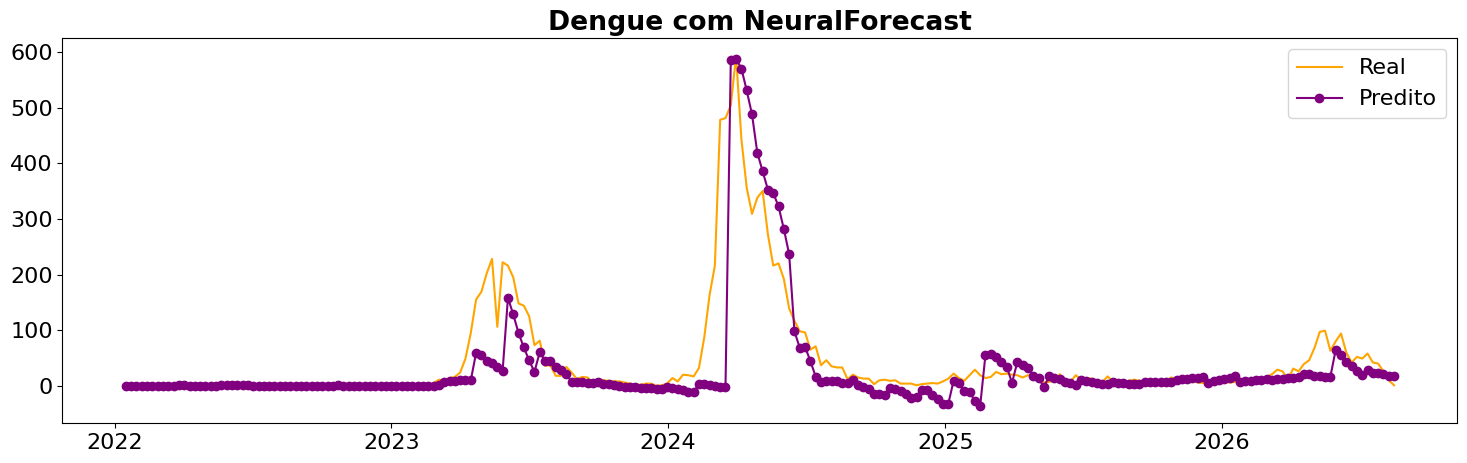

In [12]:
plotar_resultados(resultados_d, "Dengue com NeuralForecast", "Dengue")

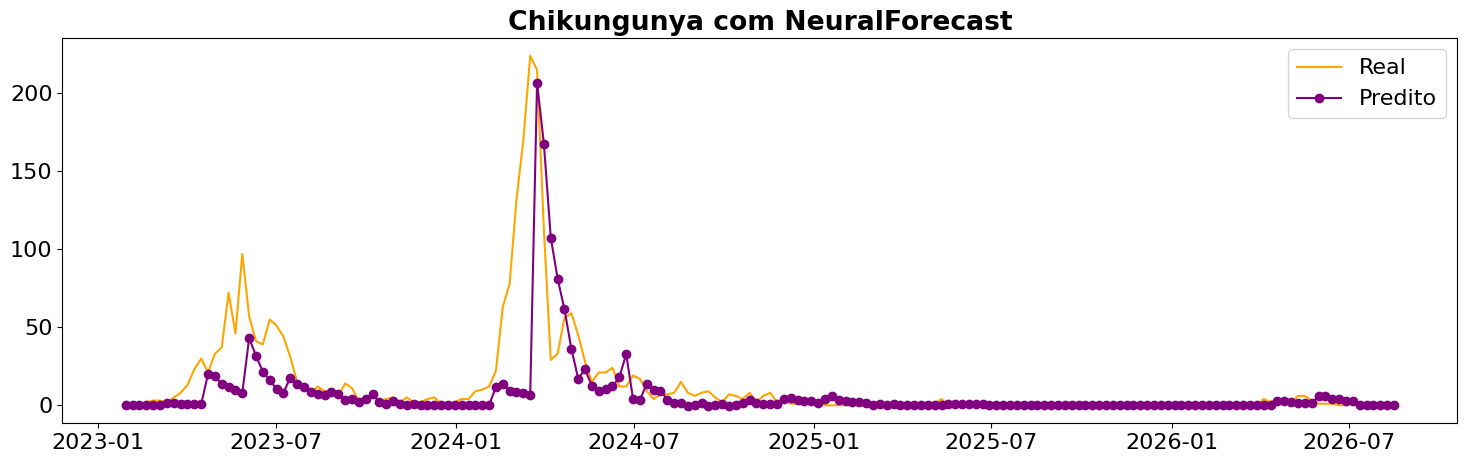

In [13]:
plotar_resultados(resultados_ch, "Chikungunya com NeuralForecast", "Chikungunya")

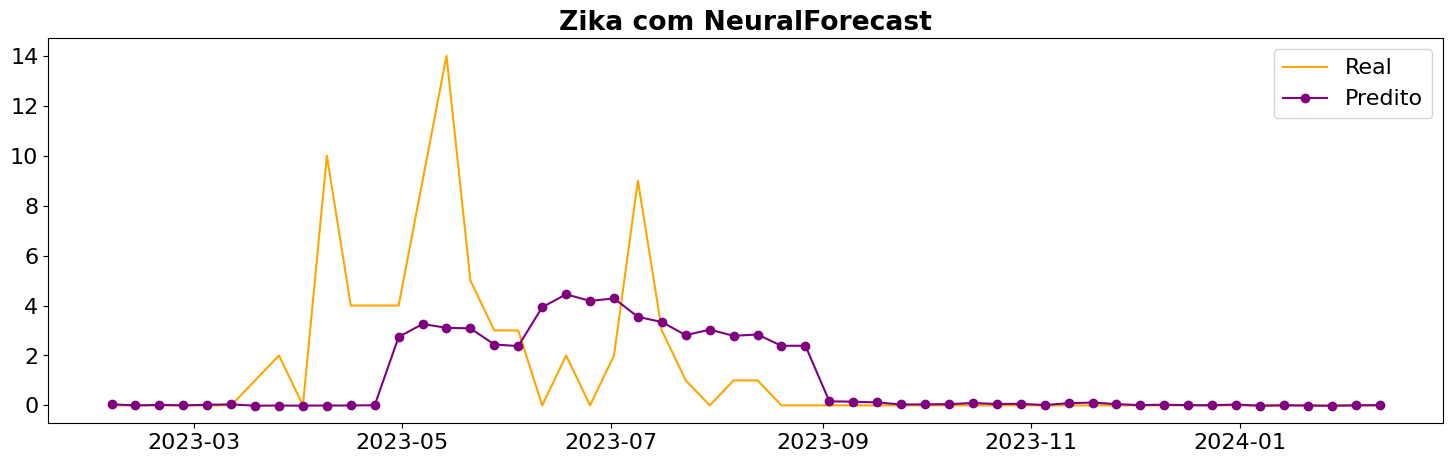

In [14]:
plotar_resultados(resultados_zk, "Zika com NeuralForecast", "Zika")

In [41]:
def salar_dataFrames(resultados, arbo, modelo, caminho):
    dados = pd.DataFrame({
    "data": resultados["ds"],
    "y": resultados["y"],
    "y_pred": resultados["MLP"]
})
    dados = dados.set_index("data")
    dados.to_csv(f"{caminho}/{modelo}_{arbo}.csv", index=True)
    

In [42]:
salar_dataFrames(resultados_d, "Dengue", "mlpforecast", "./resultados/mlpforecast")
salar_dataFrames(resultados_ch, "Chikungunya", "mlpforecast", "./resultados/mlpforecast")
salar_dataFrames(resultados_zk, "Zika", "mlpforecast", "./resultados/mlpforecast")